# ALL METHODS PLOTS

This notebook makes plots of a collection of settings, namely 

- community detection algorithms for test
- budget factor
- similarity threshold

and combine the results for a collection of datasets, evasion methods and metrics.

## Imports
 

In [39]:
from typing import List
from enum import Enum
import seaborn as sns
import os
import pandas as pd
import json
from statistics import mean
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

## Objects from utils file


In [10]:
class DatasetNames(Enum):
    """Enum class for the dataset names"""

    KAR = "kar"
    WORDS = "words"
    VOTE = "vote"
    POW = "pow"
    FB_75 = "fb-75"
    COND_MAT = "cond-mat"
   
class DetectionAlgorithmsNames(Enum):
    """Enum class for the detection algorithms"""
    
    GRE = "greedy"
    LOUV = "louvain"
    WALK = "walktrap"
    LEID = "leiden"
    INF = "infomap"
    LAB = "label_propagation"
    EIG = "leading_eigenvector"
    BTW = "edge_betweenness"
    SPIN = "spinglass"
    SCD = "scd"
    LOC = "locale"
    DGC = "dgcluster"

class EvasionAlgorithmsNames(Enum):
    RAND = "random"
    DEG = "degree"
    BETW = "betweenness"
    ROAM = "roam"
    DICE = "dice"
    NABLA = "nabla-cmh"
    DRL = "drl-agent"
    GRE = "greedy"

def check_dir(path: str):
        """
        Check if the directory exists, if not create it.

        Parameters
        ----------
        path : str
            Path to the directory
        """
        if not os.path.exists(path):
            os.makedirs(path)

## Configuration

In [113]:
evasion_algs = ["RAND", "DEG", "BETW", "ROAM", "DICE", "NABLA", "DRL"]

datasets = ["KAR", "WORDS", "VOTE", "POW"]

#community_detection_algs = ["GRE", "LOUV", "LEID", "WALK", "INF", "LAB", "SCD", "LOC", "DGC"]
detection_algs = ["GRE"]

#budget_factors = [0.5,1,2]
budget_factors = [1]

taus = [0.5]

metrics = ["goal","nmi","f1","time","steps"]

results_dir = "../outputs_review/runs"
outputs_dir = "../outputs_review"
save_dir = "../outputs_review/all_datasets"

#seeds = [22,2025,42]
seeds = [22,2025]

### Directory check

In [9]:
for seed in seeds:
    for dataset in datasets:
        for alg in detection_algs:
            for tau in taus:
                for c_beta in budget_factors:
                    dataset_name = getattr(DatasetNames, dataset).value
                    alg_name = getattr(DetectionAlgorithmsNames, alg).value
                    check_dir(results_dir + f"/seed_{seed}/{dataset_name}/{alg_name}/tau_{tau}/betaFactor_{c_beta}/plots/")  

## F1 Plot


In [123]:
def plot_f1_all_datasets(
    datasets: List[str], 
    detection_algs: List[str],
    seeds: List[int],
    taus: List[float],
    betas: List[float]
    ):
    """
    Plot the f1 scores of the evaluation on all the datasets and detection algorithms across all runs.
    The f1 scores are calculated as the harmonic mean of the goal and nmi scores.

    Parameters
    ----------
    datasets : List[str]
        List of datasets
    detection_algs : List[str]
        List of detection algorithms
    seeds : List[int]
        List of seeds
    taus : List[float]
        List of tau values
    betas : List[float]
        List of beta values
    """


    save_path = "../outputs_review/all_datasets/f1_score/"
    check_dir(save_path)

    dataset_names = [getattr(DatasetNames, dataset).value for dataset in datasets]
    evading_algs=["NABLA","DRL","RAND","DICE","DEG","ROAM","BETW"]
    community_algs = [getattr(DetectionAlgorithmsNames, alg).value for alg in detection_algs]

    # Redefine the names of the algorithms
    nabla_renamed = r"$\nabla\text{-CMH (ours)}$"
    agent_renamed = "DRL-Agent"
    random_renamed = "Random"
    dice_renamed = "DICE"
    deg_renamed = "Degree"
    roam_renamed = "ROAM"
    betweenness_renamed = "Centrality"

    f1_dict = {}
    for dataset in dataset_names:
        f1_dict[dataset] = {}
        for detection_alg in community_algs:
            f1_dict[dataset][detection_alg] = {}
            for tau in taus:
                f1_dict[dataset][detection_alg][f"tau_{tau}"] = {}
                for beta in betas:
                    f1_dict[dataset][detection_alg][f"tau_{tau}"][f"beta_{beta}"] = {}
                    for alg in evading_algs:
                        f1_dict[dataset][detection_alg][f"tau_{tau}"][f"beta_{beta}"][alg] = []
                        for seed in seeds:
                            json_path = f"{results_dir}/seed_{seed}/{dataset}/{detection_alg}/tau_{tau}/betaFactor_{beta}/plots/metrics.json"
                            with open(json_path, "r") as f:
                                log = json.load(f)
                            f1_dict[dataset][detection_alg][f"tau_{tau}"][f"beta_{beta}"][alg].append(log["f1"][alg])


    for detection_alg in community_algs:
        for tau in taus:
            for beta in betas:
                plot_data = []
                for dataset in dataset_names:
                    df = pd.DataFrame(f1_dict[dataset][detection_alg][f"tau_{tau}"][f"beta_{beta}"])
                    plot_data.append(df)
                df = pd.concat(plot_data,axis=1)
                # Replace algorithm names in evading_algs list
                evading_algs = [
                    nabla_renamed,
                    agent_renamed,
                    random_renamed,
                    dice_renamed,
                    deg_renamed,
                    roam_renamed,
                    betweenness_renamed
                ]
                # in datasets list replace "cond-mat" with "arxiv"
                datasets_renamed = ["arxiv" if dataset == "cond-mat" else dataset for dataset in dataset_names]
                df.columns = pd.MultiIndex.from_product([datasets_renamed, evading_algs])
                # Melt the dataframe
                df = df.melt(var_name=["Dataset", "Algorithm"], value_name="f1")
                max_value = df.groupby(['Dataset', 'Algorithm'])["f1"].mean().max()

                # Palette personalizzata 1
                custom_palette1 = {
                    nabla_renamed: "#033dff",  
                    agent_renamed: "#4b4d52",  
                    random_renamed: "#3d6cf5",       
                    dice_renamed: "#858ca1",     
                    deg_renamed: "#829eed",        
                    roam_renamed: "#c0c1c2",    
                    betweenness_renamed: "#c0ccf0"   
                }

                # Palette personalizzata 2
                custom_palette2 = {
                    nabla_renamed: "#0027FF",  
                    agent_renamed: "#382761",  
                    random_renamed: "#4767F5",       
                    dice_renamed: "#8172A3",     
                    deg_renamed: "#8397F0",        
                    roam_renamed: "#C0C1FF",    
                    betweenness_renamed: "#A4C1D7"   
                }

                sns.set_theme(style="whitegrid")
                #plt.rcParams['text.usetex'] = False  
                g = sns.catplot(
                    data=df,
                    kind="bar",
                    x="Dataset",
                    y="f1",
                    hue="Algorithm",
                    aspect=2,
                    palette=custom_palette2,
                    errorbar=('ci',95),
                    legend=False,
                    capsize=0.3,
                    err_kws={
                        'linewidth': .9,   
                        'color': 'black',    
                    },
                )
                ax = g.ax  
                ax.set_yticks([i * 0.1 for i in range(0, 11)])
                g.set_axis_labels("Datasets", "F1 score", fontsize=25)
                g.set_yticklabels(fontsize=20)
                g.set_xticklabels(ha="center", fontsize=25)
                custom_handles = [
                    Patch(facecolor=custom_palette2[alg], label=alg, hatch='//' if alg == "NABLA" else '')
                    for alg in df['Algorithm'].unique()
                ]
                plt.legend(handles=custom_handles, loc='upper center', bbox_to_anchor=(0.47, 1.3), frameon=False, ncol=4, fontsize=20)
                for ax in g.axes.flat:
                    ax.spines["top"].set_visible(True)
                    ax.spines["right"].set_visible(True)
                    ax.spines["top"].set_color("black")
                    ax.spines["right"].set_color("black")
                    ax.spines["left"].set_color("black")
                    ax.spines["bottom"].set_color("black")
                #indices_to_hatch_lines = [0,1,2,3,4,5] 
                indices_to_hatch_lines = [0,1,2,3] 
                for ax in g.axes.flat:  
                    bars = ax.patches  
                    bars = [bar for bar in ax.patches if bar.get_height() > 0]
                    for i, bar in enumerate(bars):  
                        if i in indices_to_hatch_lines:  
                            bar.set_hatch('//')  


                save_fig_path = f"{save_path}/{detection_alg}/tau_{tau}/beta_{beta}"
                check_dir(save_fig_path)
                g.savefig(
                    f"{save_fig_path}/f1_score_grouped.pdf",
                    bbox_inches="tight",
                    dpi=1000,
                )
                        

   

## Plot Function call

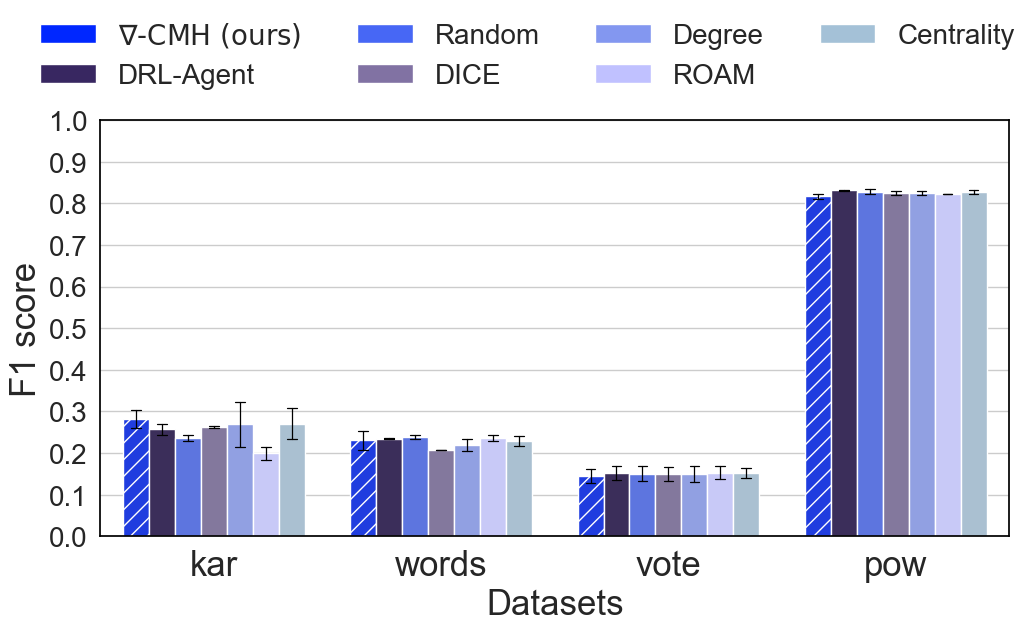

In [124]:
plot_f1_all_datasets(
    datasets= ["KAR", "WORDS", "VOTE", "POW"],
    detection_algs= ["DGC"],
    seeds=[22,2025],
    taus=[0.5],
    betas=[1],
)